>
> # Scenario analysis - Two-dimensional
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
import seaborn as sns
from scenarios import *
from plot_func import *

In [2]:
# Enter variables and data type
variable_1 = {"name": "comm-rate", "sym": "$\pi$", "int": False, "pos": 3}
variable_2 = {"name": "fare", "sym": "$f_{\mathrm{km}}$", "int": False, "pos": 5}
variables = {"variable_1": variable_1, "variable_2": variable_2}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variables["variable_1"]["name"]+'_'+variables["variable_2"]["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variables)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variables)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [4]:
vals_1 = set([i.split('_', 1)[0] for i in vals])
vals_2 = set([i.split('_', 1)[1] for i in vals])

# abc_1 = set(map(int, [i.split('_', 1)[0] for i in vals]))
# abc_2 = set(map(int, [i.split('_', 1)[1] for i in vals]))

In [12]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(5)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,45,73.499486,23,1066.535735,45,True
1,35,75.785459,23,979.033385,35,True
2,36,76.285749,22,839.333848,36,True
3,33,105.222836,23,441.573822,33,True
4,45,86.476314,46,343.833687,46,True


In [6]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/3 for scenario 0.05_0.5
Sufficient number of replications: 3/1 for scenario 0.05_0.75
Sufficient number of replications: 3/1 for scenario 0.05_1.0
Sufficient number of replications: 3/1 for scenario 0.05_1.25
Sufficient number of replications: 3/1 for scenario 0.05_1.5
Sufficient number of replications: 3/1 for scenario 0.05_1.75
Sufficient number of replications: 3/1 for scenario 0.05_2.0
Sufficient number of replications: 3/2 for scenario 0.05_2.25
Sufficient number of replications: 3/1 for scenario 0.05_2.5
Sufficient number of replications: 3/2 for scenario 0.15_0.5
Sufficient number of replications: 3/1 for scenario 0.15_0.75
Sufficient number of replications: 3/1 for scenario 0.15_1.0
Sufficient number of replications: 3/2 for scenario 0.15_1.25
Sufficient number of replications: 3/1 for scenario 0.15_1.5
Sufficient number of replications: 3/1 for scenario 0.15_1.75
Sufficient number of replications: 3/1 for scenario 0.15_2.0
Sufficient number

In [7]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [11]:
eql_scn.dem.head(5)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time,extra_bike,extra_pt,extra_car
scenario,,,,,,,,,,,,,,,,,,,,,
0.05_0.5,72519.000000,3772.666667,0.890199,3358.400000,381.392049,536.986404,701.258012,601.964758,51861.666667,10747.400000,...,270.976622,510.129838,276.132626,1783.574643,253.823701,127.568348,NaN,1879.000000,256.666667,236.666667
0.05_0.75,61695.333333,4804.800000,0.996026,4785.666667,171.673413,178.135545,231.577096,197.372126,42882.533333,9092.933333,...,185.155965,209.976776,136.957727,4551.326699,164.750949,6.922463,NaN,9845.333333,1452.666667,1456.000000
0.05_1.0,46793.000000,3695.000000,1.000000,3695.000000,136.560960,136.560960,155.586870,136.783494,32285.800000,7337.733333,...,156.605276,156.605276,95.660923,3608.533834,137.323915,-0.762955,NaN,20821.666667,2940.000000,3336.000000
0.05_1.25,33426.000000,2599.866667,1.000000,2599.866667,112.798996,112.798996,131.287656,119.169765,22828.333333,5703.266667,...,123.848588,123.848588,76.893155,2515.672876,114.483019,-1.684022,NaN,30735.333333,4209.666667,5160.000000
0.05_1.5,23290.666667,1770.400000,1.000000,1770.400000,107.029226,107.029226,120.860962,110.791348,15791.800000,4277.466667,...,111.386222,111.386222,63.331166,1712.271445,109.150595,-2.121369,NaN,38249.666667,5090.666667,6729.000000


In [13]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [15]:
# Add scenario values as columns to df
eql_scn.sup = add_scn_vals(eql_scn.sup, variables)
eql_scn.dem = add_scn_vals(eql_scn.dem, variables)
eql_scn.plf = add_scn_vals(eql_scn.plf, variables)

In [17]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])
eql_scn.soc = add_scn_vals(eql_scn.soc, variables)

In [18]:
# Change commission to percentage
eql_scn.sup['comm-rate'] = eql_scn.sup['comm-rate'] * 100
eql_scn.dem['comm-rate'] = eql_scn.dem['comm-rate'] * 100
eql_scn.plf['comm-rate'] = eql_scn.plf['comm-rate'] * 100
eql_scn.soc['comm-rate'] = eql_scn.soc['comm-rate'] * 100

In [19]:
eql_scn.sup['comm-rate'] = eql_scn.sup['comm-rate'].astype(int)
eql_scn.dem['comm-rate'] = eql_scn.dem['comm-rate'].astype(int)
eql_scn.plf['comm-rate'] = eql_scn.plf['comm-rate'].astype(int)
eql_scn.soc['comm-rate'] = eql_scn.soc['comm-rate'].astype(int)

C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:204: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\arjanderuijter\Anaconda3\envs\MS_venv\lib\site-packages\seaborn\matrix.py:209: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


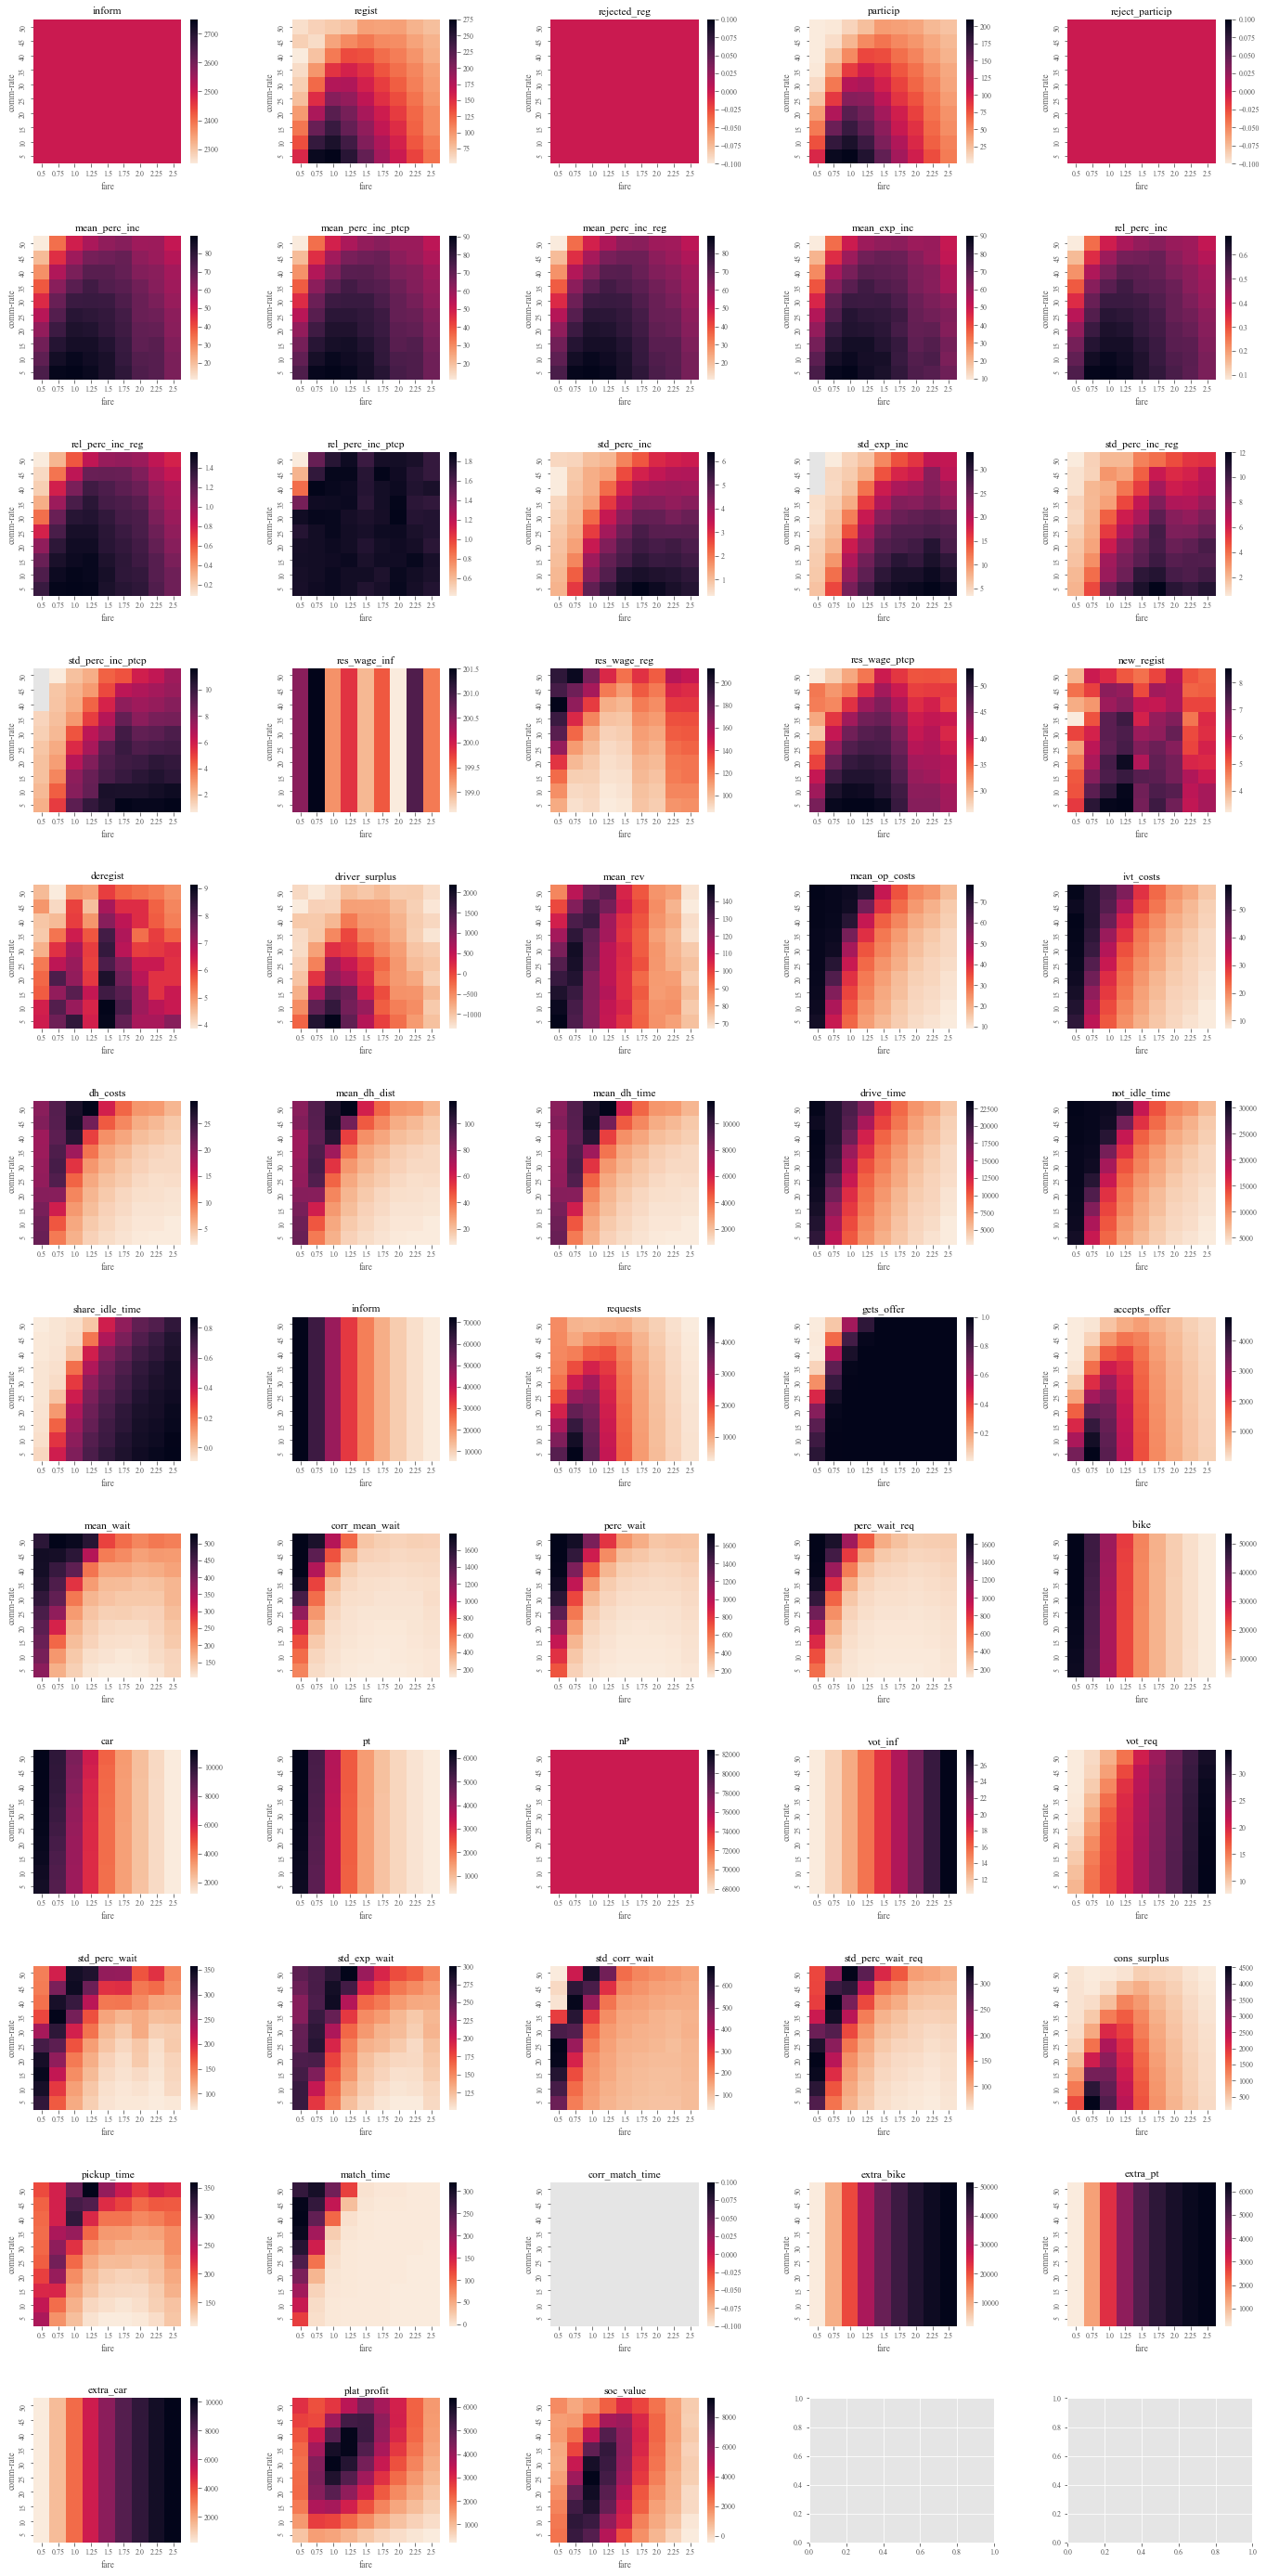

In [20]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(12, 5, figsize = [24,50])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

i = 0
j = 0
for kpi in kpis_sup:
    axes[j, i] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 4:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 4:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values = kpi), ax=axes[j,i], cmap=cmap)
    axes[j, i].set_title(kpi)
    axes[j, i].invert_yaxis()
    i += 1
    if i > 4:
        i = 0
        j += 1
        
axes[j, i] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values = 'soc_value'), ax=axes[j,i], cmap=cmap)
axes[j, i].set_title('soc_value')
axes[j, i].invert_yaxis()
# kokos = eql_scn.sup.pivot(index='nP', columns='nV', values=['inform','regist'])
# sns.heatmap(data)
# sns.heatmap(kokos)
# plt.show()
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'heat_maps.jpg'),dpi=300,bbox_inches='tight')

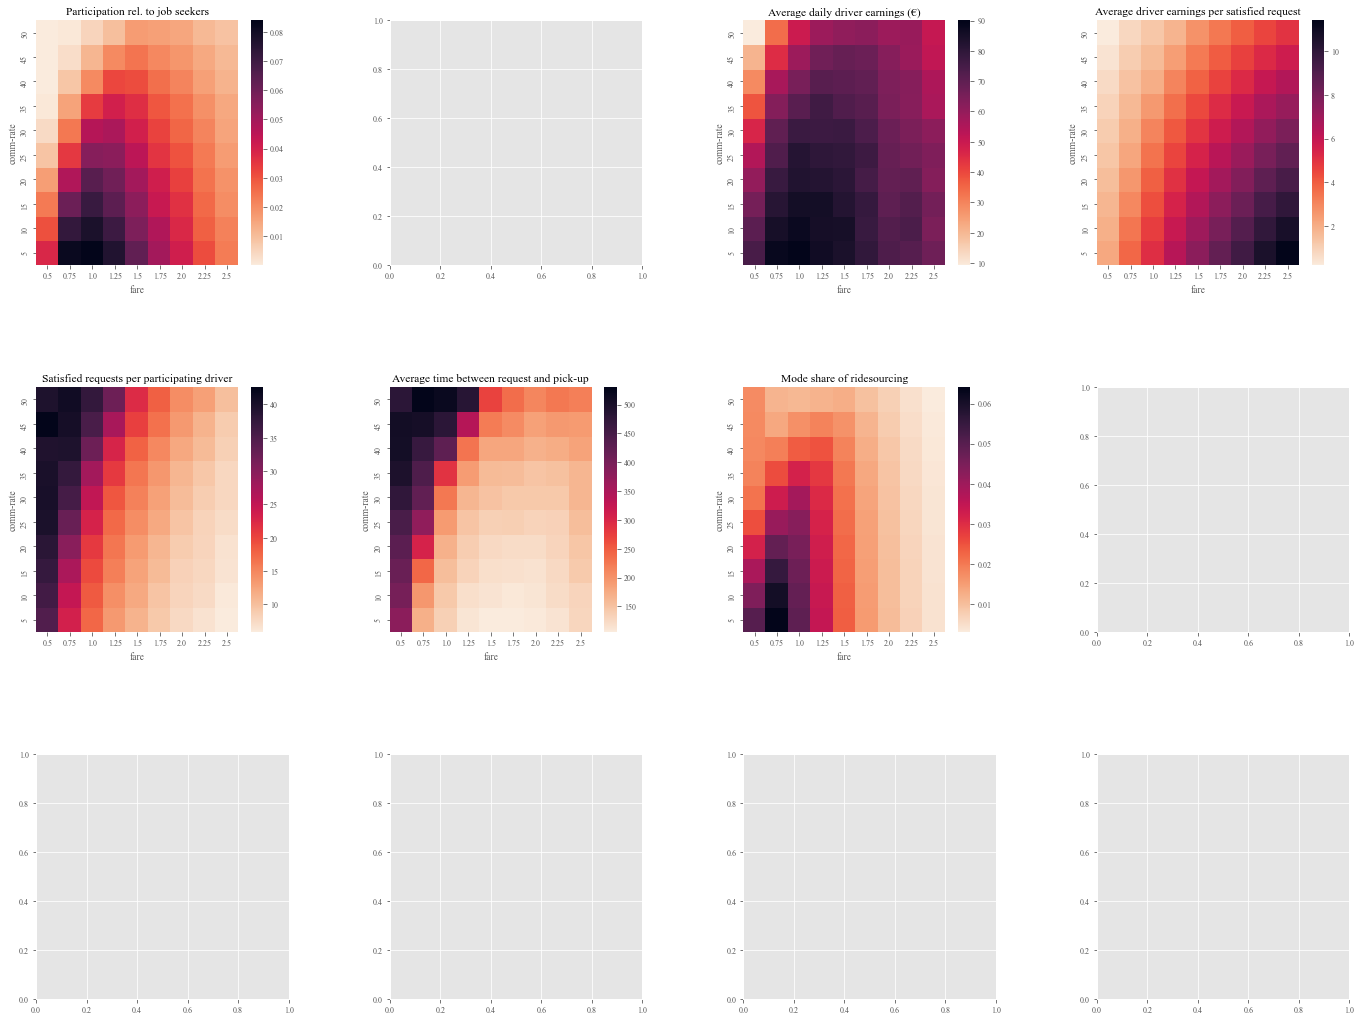

In [21]:
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 4, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)

# sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'inform'), ax=axes[0,0])
# axes[0, 1] = sns.heatmap(eql_scn.sup.pivot(index='nP', columns='nV', values = 'regist'))

res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc[variable_1['name']] = eql_scn.sup[variable_1['name']]
res_proc[variable_2['name']] = eql_scn.sup[variable_2['name']]

res_proc['part_inf'] = eql_scn.sup.particip / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='part_inf'), ax = axes[0,0], cmap=cmap)
axes[0,0].set_title('Participation rel. to job seekers')
axes[0,0].invert_yaxis()
# axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 

res_proc['part_inf'] = eql_scn.dem.requests / eql_scn.dem.nP
axes[1,2] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='part_inf'), ax = axes[1,2], cmap=cmap)
axes[1,2].set_title('Mode share of ridesourcing')
axes[1,2].invert_yaxis()
# axes[1,3].yaxis.set_major_formatter(mtick.PercentFormatter(1))  

res_proc['exp_inc'] = eql_scn.sup.mean_exp_inc.copy()
axes[0,2] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='exp_inc'), ax = axes[0,2], cmap=cmap)
axes[0,2].set_title('Average daily driver earnings (€)')
axes[0,2].invert_yaxis()

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[0,3] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='earn_req_sat'), ax = axes[0,3], cmap=cmap)
axes[0,3].set_title('Average driver earnings per satisfied request')
axes[0,3].invert_yaxis()


res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[1,0] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='serv_req_part'), ax = axes[1,0], cmap=cmap)
axes[1,0].set_title('Satisfied requests per participating driver')
axes[1,0].invert_yaxis()

res_proc['wait_time'] = eql_scn.dem.mean_wait
axes[1,1] = sns.heatmap(res_proc.pivot(index=variable_1['name'], columns=variable_2['name'], values='wait_time'), ax = axes[1,1], cmap=cmap)
axes[1,1].set_title('Average time between request and pick-up')
axes[1,1].invert_yaxis()

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'heat_maps_select.jpg'),dpi=300,bbox_inches='tight')

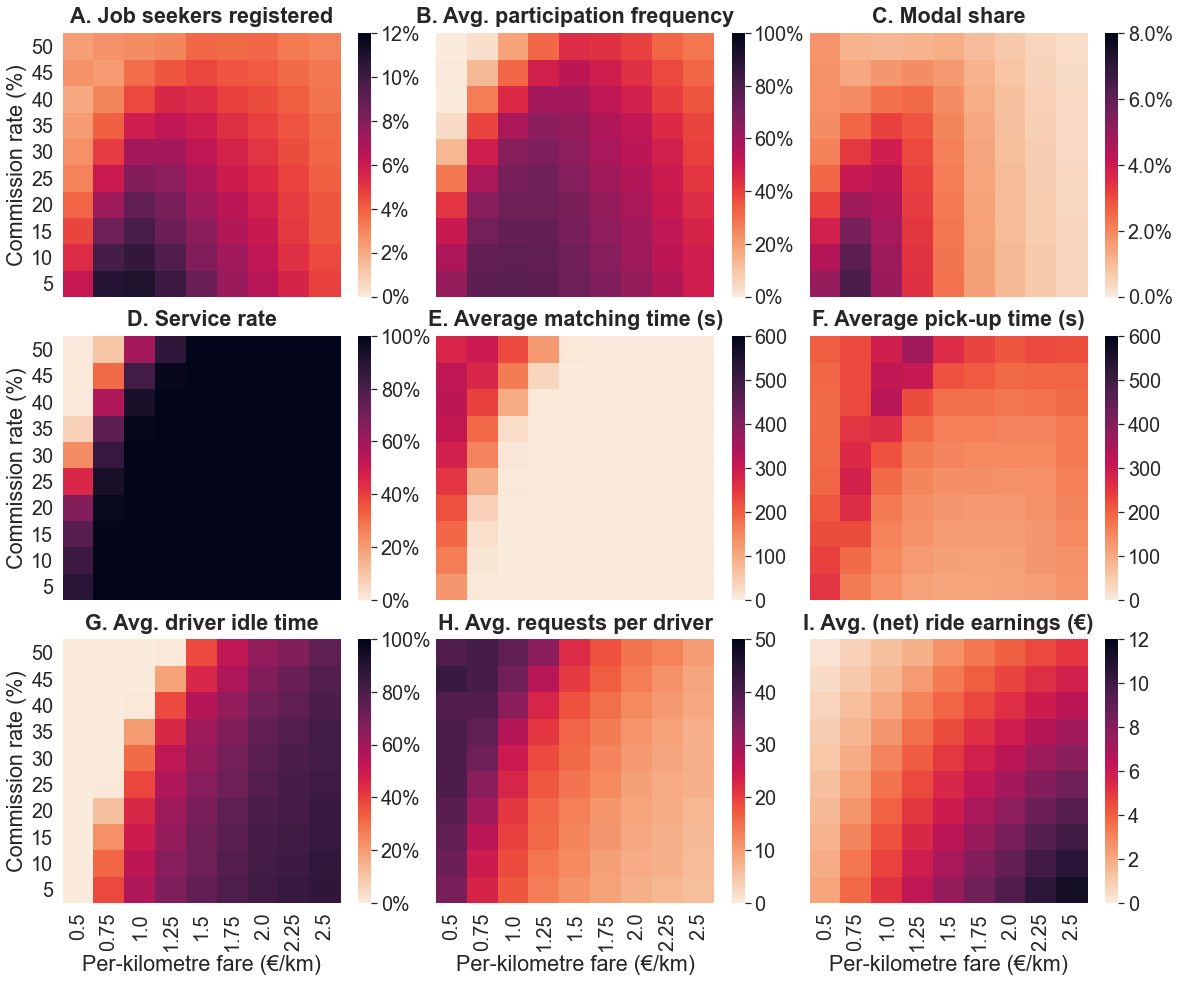

In [22]:
cmap = sns.cm.rocket_r
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(3, 3, figsize = [20,16], sharex=True, sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.15, wspace=0.075, left=.12, right=.88)


res_proc = pd.DataFrame(index = eql_scn.sup.index)
res_proc['fare'] = eql_scn.sup[variable_1['name']]
res_proc['comm-rate'] = eql_scn.sup[variable_2['name']]

res_proc['mode_share'] = eql_scn.dem.requests / eql_scn.dem.nP # eql_scn.dem.inform
axes[0,2] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='mode_share'), ax = axes[0,2], cmap=cmap, vmin=0, vmax=0.08)
cbar = axes[0,2].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 1))
axes[0,2].set_title('C. Modal share', fontweight="bold", pad=10)
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0,2].set_ylabel('Commission rate (%)')
axes[0,2].xaxis.label.set_visible(False)
axes[0,2].yaxis.label.set_visible(False)

res_proc['earn_req_sat'] = eql_scn.sup.mean_exp_inc * eql_scn.sup.particip / (eql_scn.dem.requests * eql_scn.dem.gets_offer)
axes[2,2] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='earn_req_sat'), ax = axes[2,2], cmap=cmap, vmin=0, vmax=12)
axes[2,2].set_title('I. Avg. (net) ride earnings (\u20ac)', fontweight="bold", pad=10)
axes[2,2].invert_yaxis()
axes[2,2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2,2].set_ylabel('Commission rate (%)')
axes[2,2].yaxis.label.set_visible(False)

res_proc['serv_req_part'] = eql_scn.dem.gets_offer * eql_scn.dem.requests / eql_scn.sup.particip 
axes[2,1] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='serv_req_part'), ax = axes[2,1], cmap=cmap, vmin=0, vmax=50)
axes[2,1].set_title('H. Avg. requests per driver', fontweight="bold", pad=10)
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2,1].set_ylabel('Commission rate (%)')
axes[2,1].yaxis.label.set_visible(False)

res_proc['idle_time'] = eql_scn.sup.share_idle_time
axes[2,0] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='idle_time'), ax = axes[2,0], cmap=cmap, vmin=0, vmax=1)
axes[2,0].set_title('G. Avg. driver idle time', fontweight="bold", pad=10)
cbar = axes[2,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2,0].set_ylabel('Commission rate (%)')
axes[2,0].set_yticklabels(axes[2,0].get_yticklabels(), rotation = 0)

res_proc['regist'] = eql_scn.sup.regist / eql_scn.sup.inform
axes[0,0] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='regist'), ax = axes[0,0], cmap=cmap, vmin=0, vmax=0.12)
cbar = axes[0,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,0].set_title('A. Job seekers registered', fontweight="bold", pad=10)
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0,0].set_ylabel('Commission rate (%)')
axes[0,0].xaxis.label.set_visible(False)
axes[0,0].set_yticklabels(axes[0,0].get_yticklabels(), rotation = 0)

res_proc['ptcp_prob'] = eql_scn.sup.particip / eql_scn.sup.regist
axes[0,1] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='ptcp_prob'), ax = axes[0,1], cmap=cmap, vmin=0, vmax=1)
cbar = axes[0,1].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[0,1].set_title('B. Avg. participation frequency', fontweight="bold", pad=10)
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0,1].set_ylabel('Commission rate (%)')
axes[0,1].xaxis.label.set_visible(False)
axes[0,1].yaxis.label.set_visible(False)

res_proc['match_rate'] = eql_scn.dem.gets_offer.copy()
axes[1,0] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='match_rate'), ax = axes[1,0], cmap=cmap, vmin=0, vmax=1)
cbar = axes[1,0].collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
axes[1,0].set_title('D. Service rate', fontweight="bold", pad=10)
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1,0].set_ylabel('Commission rate (%)')
axes[1,0].xaxis.label.set_visible(False)
axes[1,0].set_yticklabels(axes[1,0].get_yticklabels(), rotation = 0)

res_proc['match_time'] = eql_scn.dem.match_time.copy()
axes[1,1] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='match_time'), ax = axes[1,1], cmap=cmap, vmin=0, vmax=600)
axes[1,1].set_title('E. Average matching time (s)', fontweight="bold", pad=10)
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1,1].set_ylabel('Commission rate (%)')
axes[1,1].xaxis.label.set_visible(False)
axes[1,1].yaxis.label.set_visible(False)

res_proc['pickup_time'] = eql_scn.dem.pickup_time.copy()
axes[1,2] = sns.heatmap(res_proc.pivot(index='fare', columns='comm-rate', values='pickup_time'), ax = axes[1,2], cmap=cmap, vmin=0, vmax=600)
axes[1,2].set_title('F. Average pick-up time (s)', fontweight="bold", pad=10)
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1,2].set_ylabel('Commission rate (%)')
axes[1,2].yaxis.label.set_visible(False)
axes[1,2].xaxis.label.set_visible(False)

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'pricing_heat_main.jpg'),dpi=300,bbox_inches='tight')

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

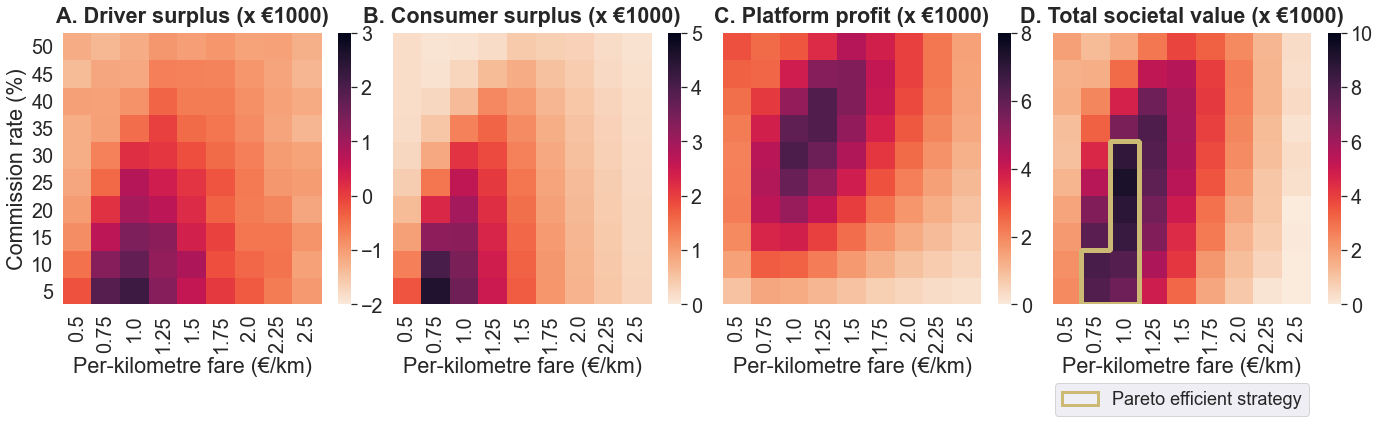

In [25]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,5],sharey=True)
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.55, wspace=0.02, left=.12, right=.88)

axes[0] = sns.heatmap(eql_scn.sup.pivot(index=variable_1['name'], columns=variable_2['name'], values='driver_surplus')/1000, ax = axes[0], cmap=cmap, vmin=-2, vmax=3)
axes[0].set_title('A. Driver surplus (x \u20ac1000)',fontweight="bold",pad=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[0].set_ylabel('Commission rate (%)')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation = 0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 90)

axes[1] = sns.heatmap(eql_scn.dem.pivot(index=variable_1['name'], columns=variable_2['name'], values='cons_surplus')/1000, ax = axes[1], cmap=cmap, vmin=0, vmax=5)
axes[1].set_title('B. Consumer surplus (x \u20ac1000)',fontweight="bold",pad=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[1].set_ylabel('Commission rate (%)')
axes[1].yaxis.label.set_visible(False)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 90)

axes[2] = sns.heatmap(eql_scn.plf.pivot(index=variable_1['name'], columns=variable_2['name'], values='plat_profit')/1000, ax = axes[2], cmap=cmap, vmin=0, vmax=8)
axes[2].set_title('C. Platform profit (x \u20ac1000)',fontweight="bold",pad=10)
axes[2].invert_yaxis()
axes[2].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[2].set_ylabel('Commission rate (%)')
axes[2].yaxis.label.set_visible(False)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation = 90)

axes[3] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='soc_value')/1000, ax = axes[3], cmap=cmap, vmin=0, vmax=10)
axes[3].set_title('D. Total societal value (x \u20ac1000)',fontweight="bold",pad=10)
axes[3].invert_yaxis()
axes[3].set_xlabel('Per-kilometre fare (\u20ac/km)')
axes[3].set_ylabel('Commission rate (%)')
axes[3].yaxis.label.set_visible(False)
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation = 90)
from matplotlib.patches import Rectangle, Polygon

array = np.array([[1,0],[3,0],[3,6],[2,6],[2,2],[1,2]])
axes[3].add_patch(Polygon(array, closed=True, linewidth=-5, ec='y', fill=False))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="None", linewidth=3, edgecolor='y', 
                         label='Pareto efficient strategy')]

axes[3].legend(handles=legend_elements,fontsize=18, loc='center', bbox_to_anchor=(0.5, -0.35))

fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'pricing_soc.jpg'),dpi=300,bbox_inches='tight')

Text(174.85999999999999, 0.5, 'Commission rate')

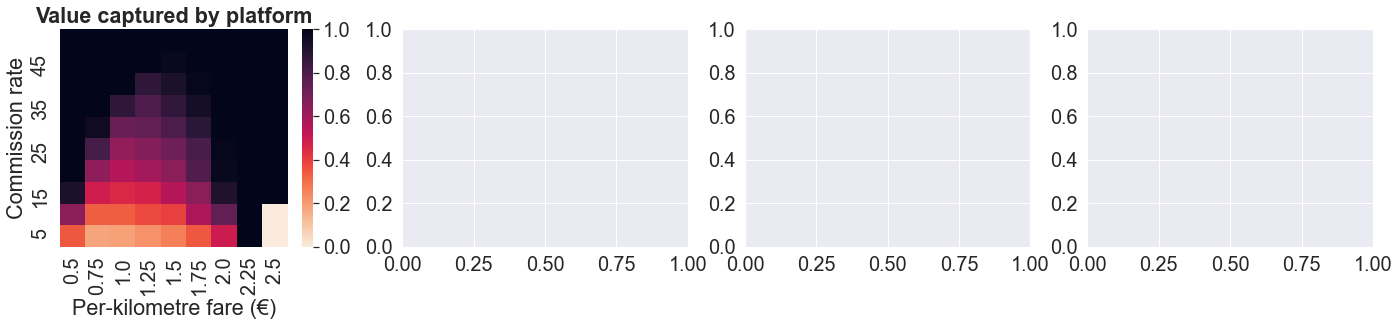

In [26]:
sns.set(font_scale=1.8)
plt.rcParams['font.weight'] = "normal"
cmap = sns.cm.rocket_r
# Create pivot tables (incl. missing scenarios as NaNs)
fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.2, left=.12, right=.88)

eql_scn.soc['rel_profit'] = eql_scn.plf.plat_profit / eql_scn.soc.soc_value
axes[0] = sns.heatmap(eql_scn.soc.pivot(index=variable_1['name'], columns=variable_2['name'], values='rel_profit'), ax = axes[0], cmap=cmap, vmin=0, vmax=1)
axes[0].set_title('Value captured by platform',fontweight="bold")
axes[0].invert_yaxis()
axes[0].set_xlabel('Per-kilometre fare (\u20ac)')
axes[0].set_ylabel('Commission rate')

In [27]:
# res_proc.to_csv('res_proc.csv')

In [28]:
# eql_scn.sup.to_csv('eql_scn_sup.csv')
# eql_scn.dem.to_csv('eql_scn_dem.csv')
# eql_scn.plf.to_csv('eql_scn_plf.csv')

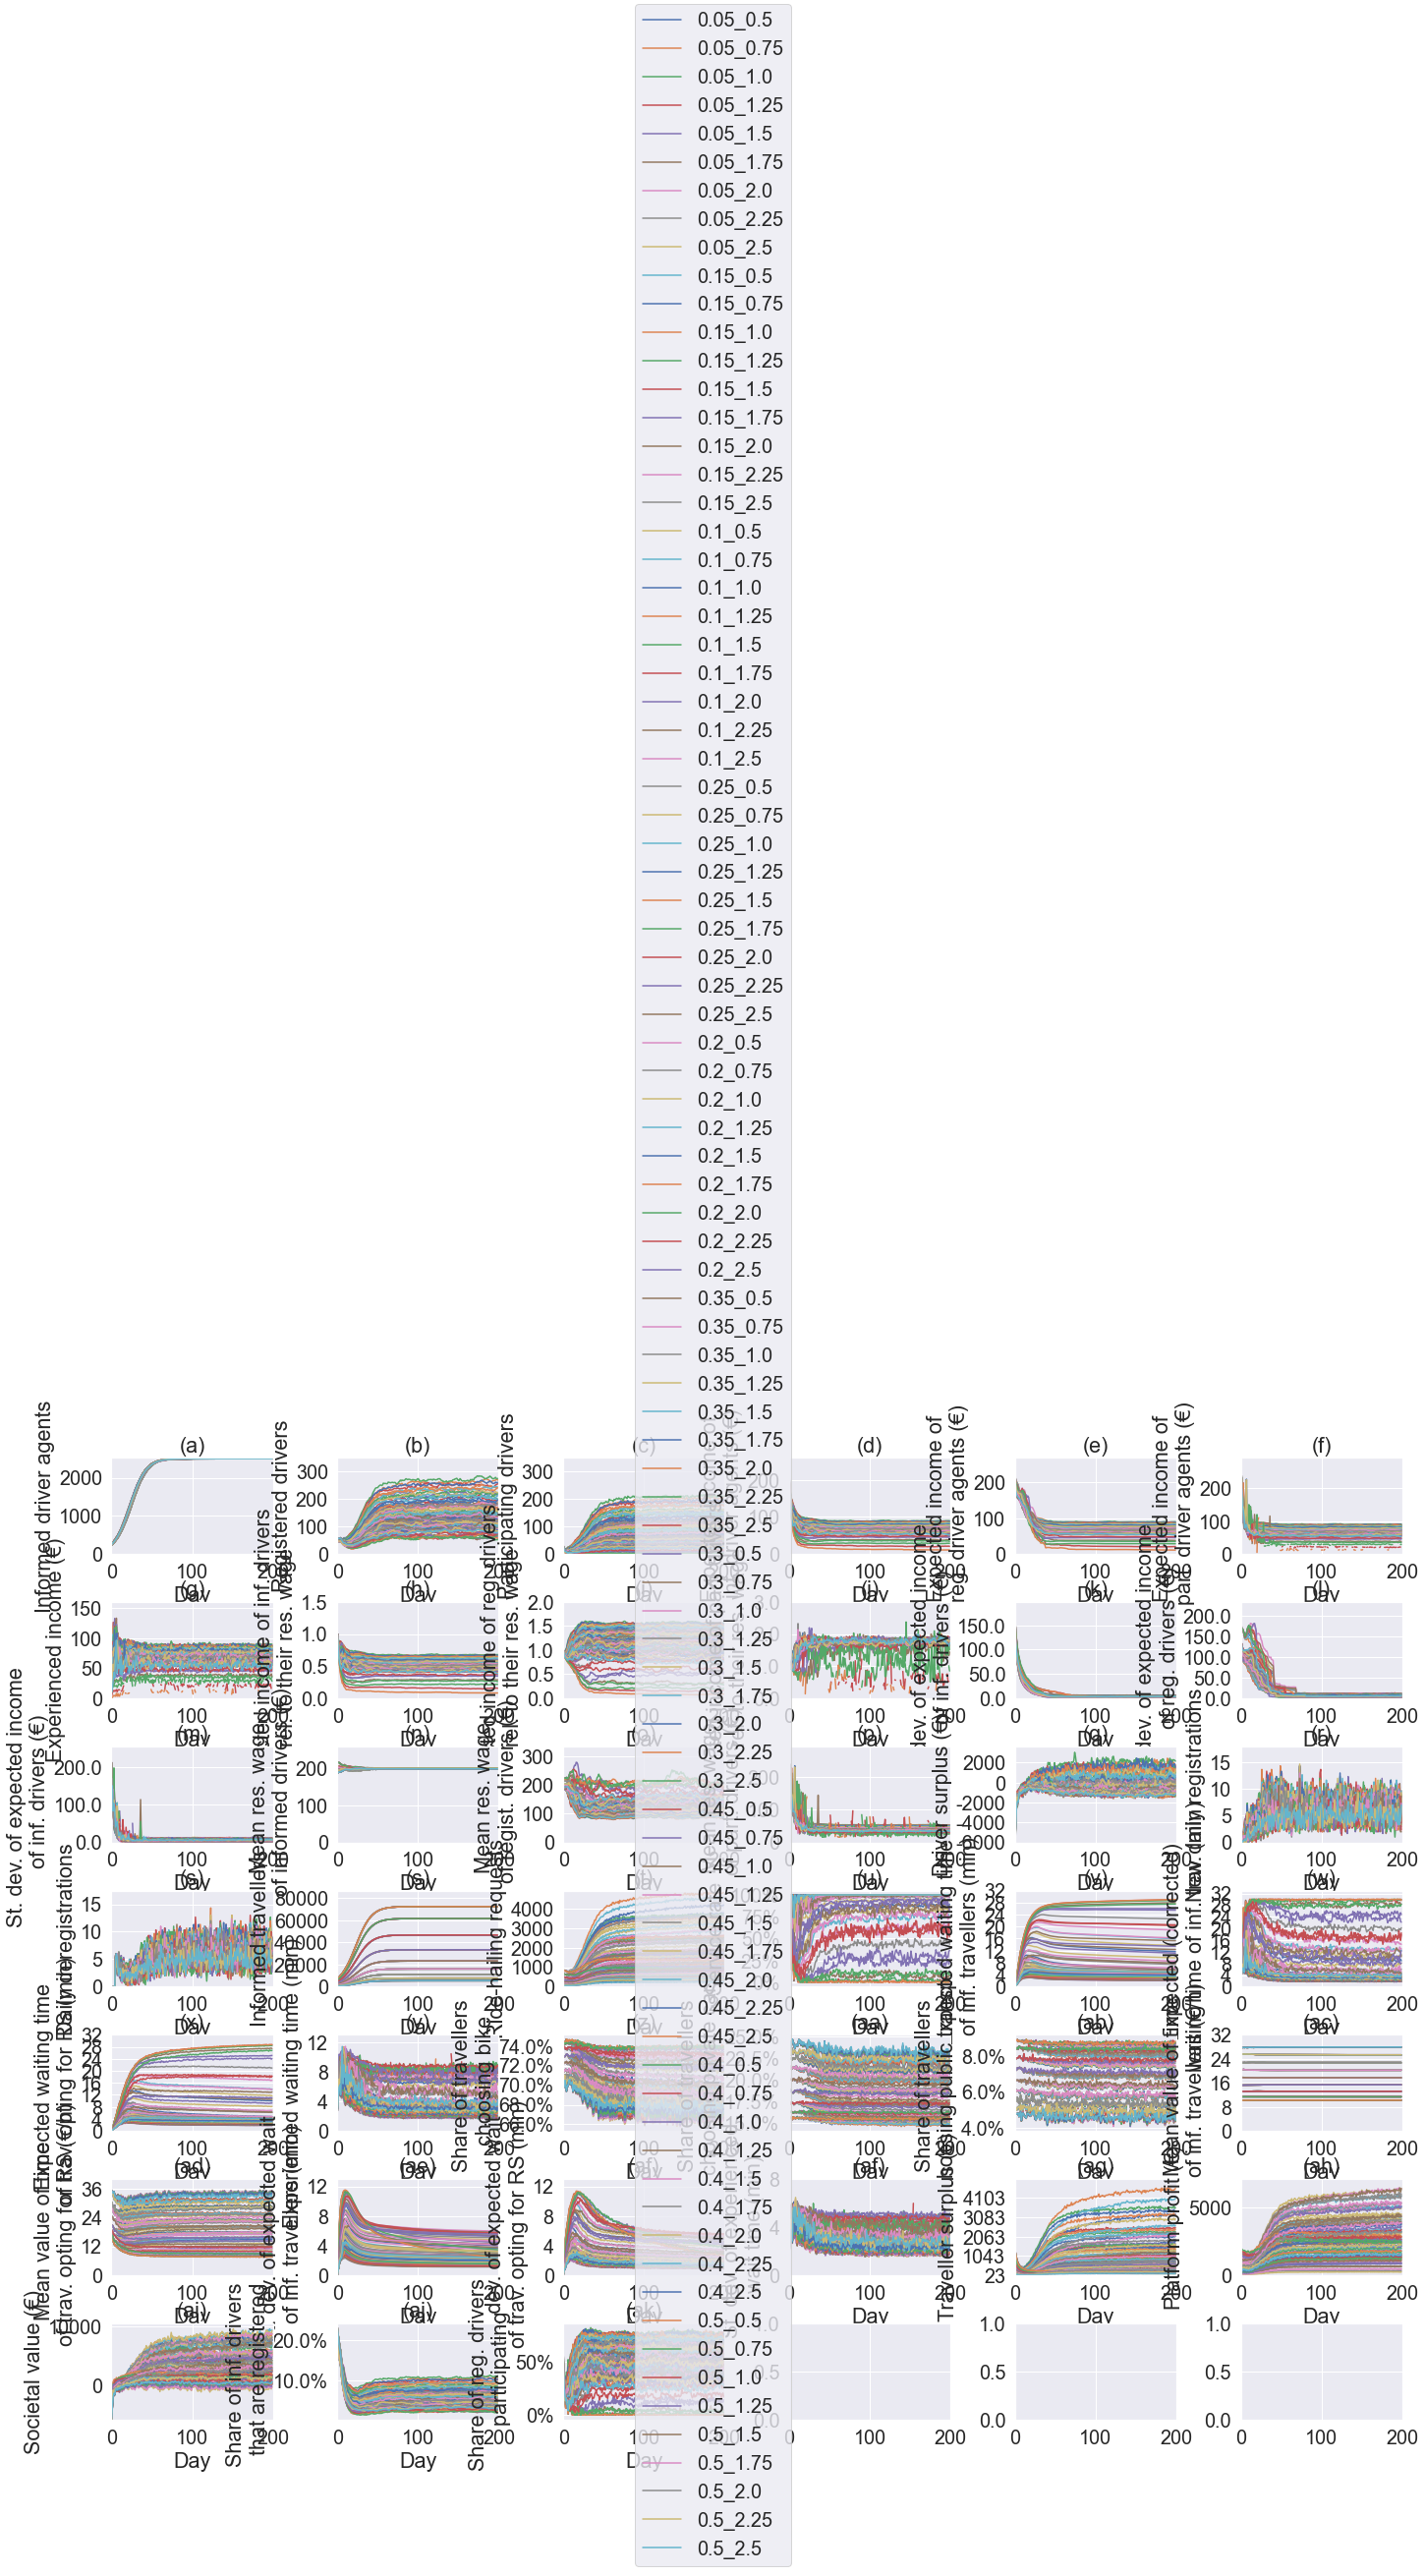

In [30]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable_1["name"] + '_' + variable_2["name"], 'dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

---